In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import onnxruntime as ort
import numpy as np

In [2]:
# load prefill model
MODEL_DIR = "/export2/obasit/ClusterLevelServing/DistServe/simdistserve/estimators/tree_models/"
pre = ort.InferenceSession(MODEL_DIR + "/prefill_model_latency.onnx")
dec = ort.InferenceSession(MODEL_DIR + "/decode_model_latency.onnx")
# pre_p = ort.InferenceSession(MODEL_DIR + "/prefill_model_power.onnx")
pre_p = ort.InferenceSession("/export2/obasit/ClusterLevelServing/vllm_logs/energy_profiler_logs/models_tree/prefill_model.onnx")
dec_p = ort.InferenceSession(MODEL_DIR + "/decode_model_power.onnx")


def infer(model, tokens, tp, freq):
    FEATURE_COLS = [
        "batch_size",
        "input_len_sum",
        "input_len_mean",
        "input_len_std",
        "tp_degree",
        "freq_mhz",
        "model"
    ]

    X = pd.DataFrame([{
        "batch_size": len(tokens),
        "input_len_sum": sum(tokens),
        "input_len_mean": float(np.mean(tokens)),
        "input_len_std": float(np.std(tokens)),
        "tp_degree": tp,
        "freq_mhz": freq,
        "model": "Llama-3.3-70B-Instruct"
    }], columns=FEATURE_COLS)


    input_feed = {}
    for col in FEATURE_COLS:
        val = X[col].values.reshape(-1, 1)
        if X[col].dtype == object or col == "model":
            input_feed[col] = val.astype(str)
        else:
            input_feed[col] = val.astype("float32")

    inputs = input_feed
    outputs = model.run(None, inputs)
    return outputs

def infer_prefill(model, tokens, tp, freq, rate):
    FEATURE_COLS = [
        "batch_size",
        "input_len_sum",
        "input_len_mean",
        "input_len_std",
        "tp_degree",
        "freq_mhz",
        "model",
        "rate"
    ]

    X = pd.DataFrame([{
        "batch_size": len(tokens),
        "input_len_sum": sum(tokens),
        "input_len_mean": float(np.mean(tokens)),
        "input_len_std": float(np.std(tokens)),
        "tp_degree": tp,
        "freq_mhz": freq,
        "model": "Llama-3.3-70B-Instruct",
        "rate": rate
    }], columns=FEATURE_COLS)


    input_feed = {}
    for col in FEATURE_COLS:
        val = X[col].values.reshape(-1, 1)
        if X[col].dtype == object or col == "model":
            input_feed[col] = val.astype(str)
        else:
            input_feed[col] = val.astype("float32")

    inputs = input_feed
    outputs = model.run(None, inputs)
    return outputs

def compute_power_w(df_power_sub: pd.DataFrame):
    energy_j = 0.0
    gpu_power_cols = [col for col in df_power_sub.columns if col.startswith("GPU_") and col.endswith("_power_w")]

    for col in gpu_power_cols:
        energy_j += np.trapezoid(df_power_sub[col], df_power_sub['Timestamp'])

    duration = df_power_sub['Timestamp'].max() - df_power_sub['Timestamp'].min()
    if duration == 0:
        return 0.0, 0.0
    return (energy_j / duration), energy_j

def plot_power_model_prefill(path, tp_degree, freq):
    df_stats = pd.read_csv(path + '/engine_0.csv')
    df_power = pd.read_csv(path + '/power_log.csv')

    df_stats['num_prompt_tokens_reqs_evald'] = df_stats['num_prompt_tokens_reqs'].apply(eval)

    # drop empty rows first
    df_stats = df_stats[df_stats['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x) > 0)].copy()
    # then do shift of gpu times
    df_stats.loc[:, "step_with_batch_queue_time_ms"] = df_stats["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)

    df_stats['rps'] = 0.0
    df_stats['diff_time'] = df_stats['now'].diff().fillna(1)
    alpha = 0.8
    for row in df_stats.itertuples():
        if row.num_prompt_tokens_reqs_evald:
            rps = len(row.num_prompt_tokens_reqs_evald) / row.diff_time
            prev_rps = df_stats['rps'].shift().fillna(0.0).loc[row.Index]
            df_stats.loc[row.Index, 'rps'] = alpha * rps + (1 - alpha) * prev_rps

    df_stats['start_times'] = df_stats['now'] - df_stats['step_with_batch_queue_time_ms'] / 1000.0

    real_power_w = []
    predicted_power_w = []
    skip_indices = []
    for row in df_stats.itertuples():
        # get real power
        start_time = row.start_times
        end_time = row.start_times + row.step_with_batch_queue_time_ms / 1000.0
        df_power_sub = df_power[(df_power['Timestamp'] >= start_time+0.1) & (df_power['Timestamp'] <= end_time+0.1)]
        power_w, _ = compute_power_w(df_power_sub)
        if power_w == 0.0:
            skip_indices.append(row.Index)
            continue
        real_power_w.append(power_w)

        # infer predicted power
        rate = row.rps
        prefill_power_pred = infer_prefill(pre_p, row.num_prompt_tokens_reqs_evald, tp_degree, freq, rate)[0][0][0]
        predicted_power_w.append(prefill_power_pred)

    # print MAPE
    real_power_w = np.array(real_power_w[:-1])
    predicted_power_w = np.array(predicted_power_w[:-1])
    mape = np.mean(np.abs((real_power_w - predicted_power_w) / real_power_w)) * 100
    print(f"Prefill Power Model MAPE: {mape}%")


    df_stats = df_stats.drop(index=skip_indices).reset_index(drop=True)
    # plot results
    plt.figure(figsize=(16, 6))
    plt.plot(df_stats.index[:-1], real_power_w, label='Real Power (W)', marker='o')
    plt.plot(df_stats.index[:-1], predicted_power_w, label='Predicted Power (W)', marker='x')
    plt.xlabel('Batch Index')
    plt.ylabel('Power (W)')
    plt.title('Real vs Predicted Power Consumption for Prefill')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

def plot_cumulative_compute_energy(path, tp_degree, freq):
    df_stats = pd.read_csv(path + '/engine_0.csv')
    df_power = pd.read_csv(path + '/power_log.csv')

    df_stats['num_prompt_tokens_reqs_evald'] = df_stats['num_prompt_tokens_reqs'].apply(eval)

    # drop empty rows first
    df_stats = df_stats[df_stats['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x) > 0)].copy()
    # then do shift of gpu times
    df_stats.loc[:, "step_with_batch_queue_time_ms"] = df_stats["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)

    df_stats['rps'] = 0.0
    df_stats['diff_time'] = df_stats['now'].diff().fillna(1)
    alpha = 0.8
    for row in df_stats.itertuples():
        if row.num_prompt_tokens_reqs_evald:
            rps = len(row.num_prompt_tokens_reqs_evald) / row.diff_time
            prev_rps = df_stats['rps'].shift().fillna(0.0).loc[row.Index]
            df_stats.loc[row.Index, 'rps'] = alpha * rps + (1 - alpha) * prev_rps

    df_stats['start_times'] = df_stats['now'] - df_stats['step_with_batch_queue_time_ms'] / 1000.0

    real_energy = []
    predicted_energy = []
    skip_indices = []
    for row in df_stats.itertuples():
        # get real power
        start_time = row.start_times
        end_time = row.start_times + row.step_with_batch_queue_time_ms / 1000.0
        df_power_sub = df_power[(df_power['Timestamp'] >= start_time+0.1) & (df_power['Timestamp'] <= end_time+0.1)]
        _, energy = compute_power_w(df_power_sub)
        if energy == 0.0:
            skip_indices.append(row.Index)
            continue
        real_energy.append(energy)

        # Assume accurate compute latency
        # decode_latency_pred = infer(dec, row.num_decode_tokens_reqs_evald, tp_degree, freq)[0][0][0]
        decode_latency_pred = row.step_with_batch_queue_time_ms / 1000.0
        power_w = infer_prefill(pre_p, row.num_prompt_tokens_reqs_evald, tp_degree, freq, row.rps)[0][0][0]
        predicted_energy_j = power_w * decode_latency_pred
        predicted_energy.append(predicted_energy_j)

    # print MAPE
    real_energy = np.array(real_energy[:-1])
    predicted_energy = np.array(predicted_energy[:-1])
    mape = np.mean(np.abs((real_energy - predicted_energy) / real_energy)) * 100
    print(f"Decode Energy Model MAPE: {mape}%") 

    #plot cumulative energies
    plt.figure(figsize=(16, 6))
    plt.plot(np.cumsum(real_energy), label='Real Energy (J)')
    plt.plot(np.cumsum(predicted_energy), label='Predicted Energy (J)')
    plt.xlabel('Batch Index')
    plt.ylabel('Cumulative Energy')
    plt.title('Cumulative Real vs Predicted Energy Consumption')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


Prefill Power Model MAPE: 26.68668164119936%


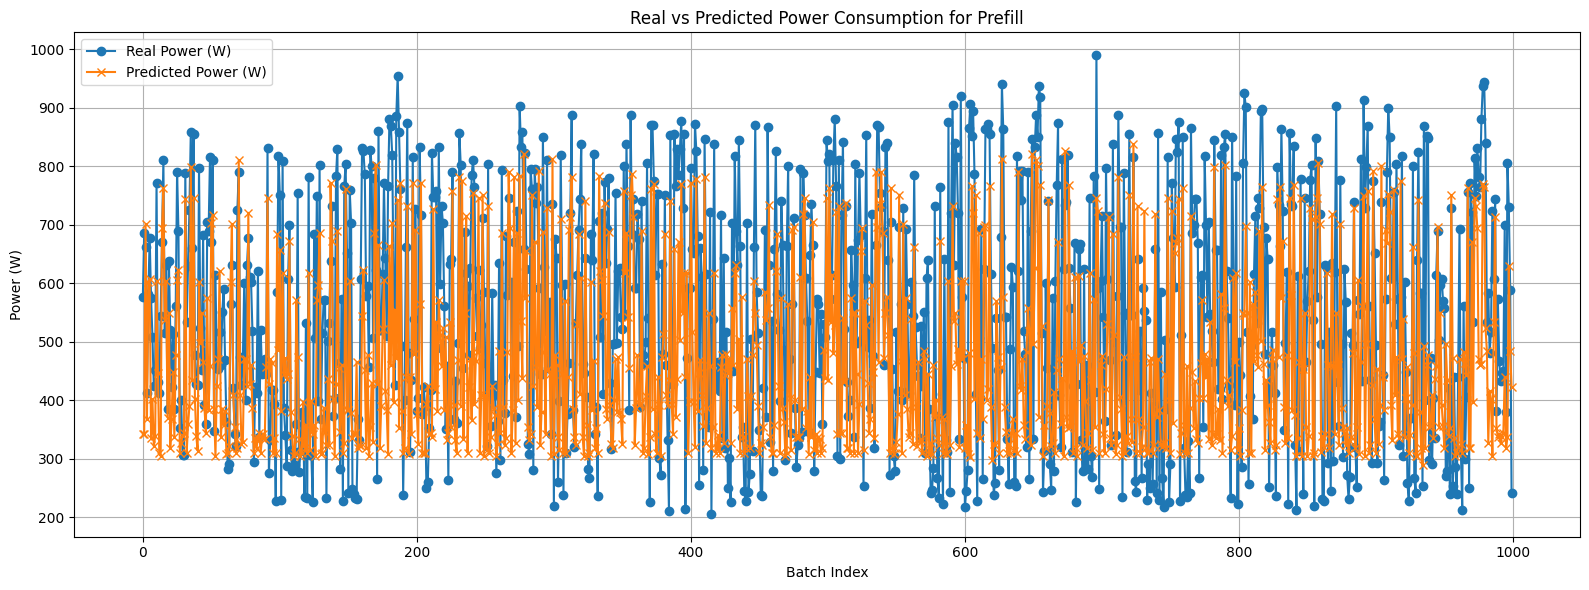

Decode Energy Model MAPE: 32.12403326797057%


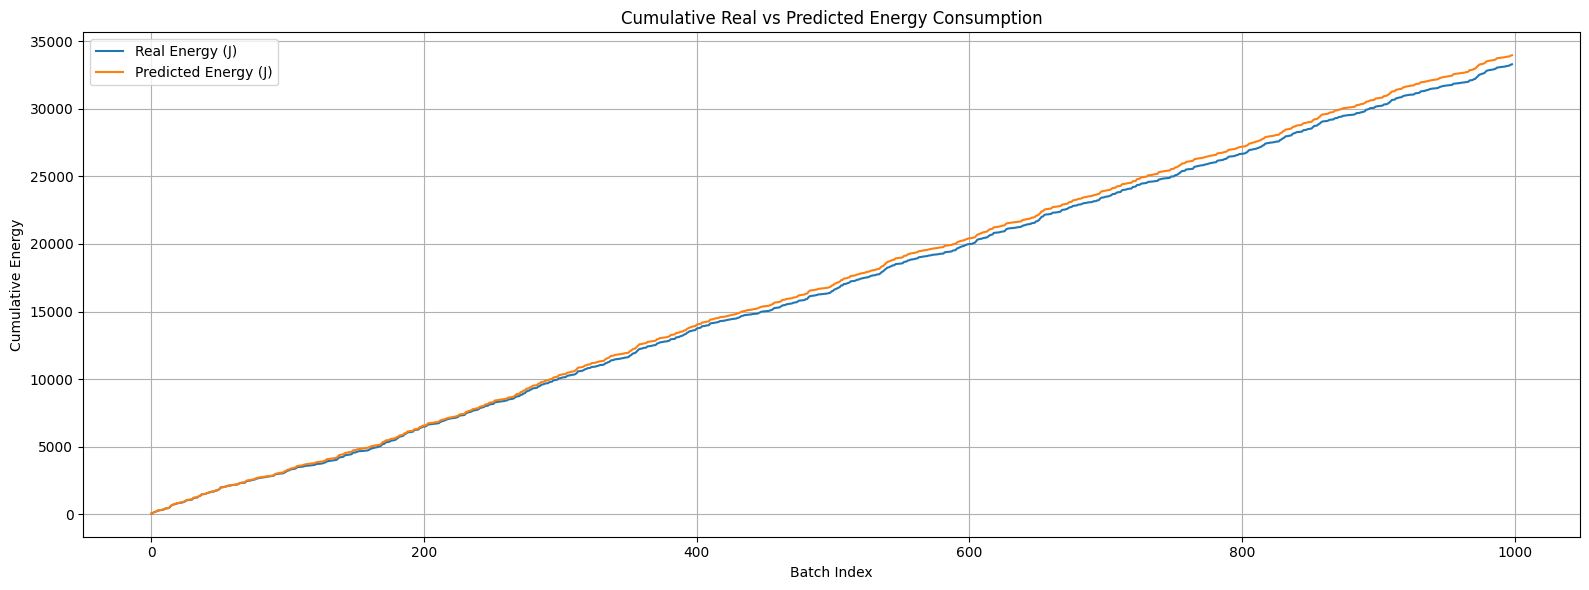

In [3]:
path = '/export2/obasit/ClusterLevelServing/vllm_logs/energy_profiler_logs/profiler_logs_prefill_real_arrival_eval/profiler_logs_Oct18_TP2_seed1k_rps4_freq1080_b1/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP2Prefill_1xTP2/default_log_path/prefill_0_Oct18064644'
freq = 1080
tp_degree = 2
plot_power_model_prefill(path, tp_degree, freq)
plot_cumulative_compute_energy(path, tp_degree, freq)

Prefill Power Model MAPE: 33.19042945398268%


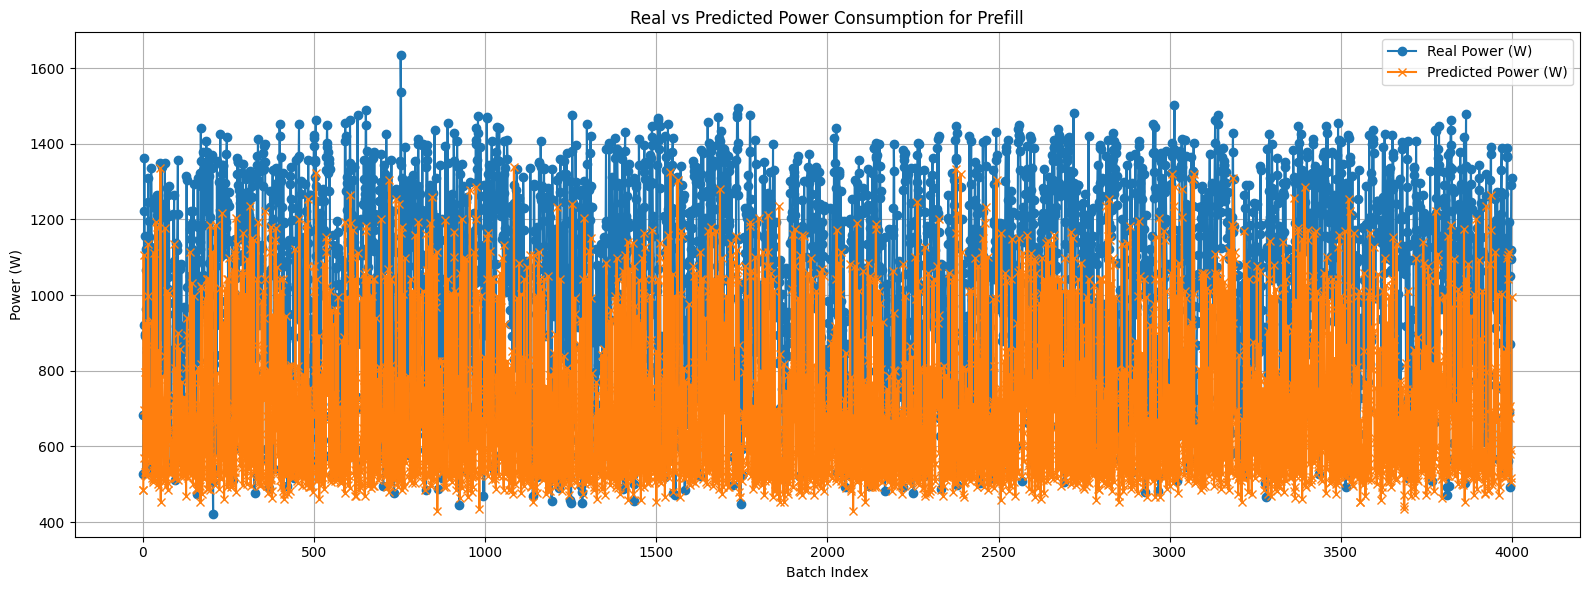

Decode Energy Model MAPE: 24.638888161333085%


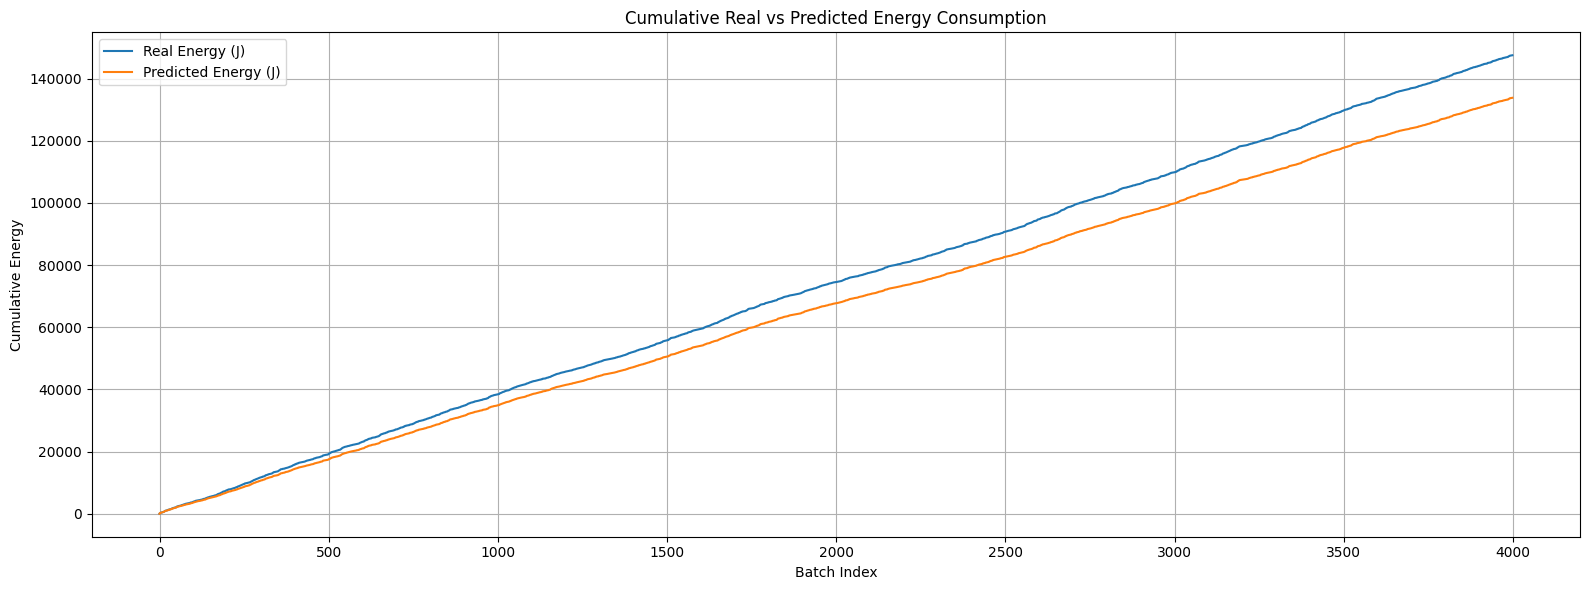

In [4]:
path = '/export2/obasit/ClusterLevelServing/vllm_logs/energy_profiler_logs/profiler_logs_prefill_real_arrival_eval/profiler_logs_Oct18_TP4_seed1k_rps15_freq1080_b1/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/default_log_path/prefill_0_Oct18061401'
freq = 1080
tp_degree = 4
plot_power_model_prefill(path, tp_degree, freq)
plot_cumulative_compute_energy(path, tp_degree, freq)